In [57]:
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
import torch.nn.functional as F
import pickle
from model_training import train
from sklearn.metrics import f1_score, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
from model_training.autoencoder import WaveAutoencoder, WaveDataset

In [2]:
with open('dataset_arcsinh.pkl', 'rb') as f:
    samples = pickle.load(f)

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [47]:
def train_autoencoder(model, dataset, device="cuda", epochs=30, batch_size=64, lr=1e-3):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for x in loader:
            x = x.to(device)

            x_hat = model(x)
            loss = F.mse_loss(x_hat, x)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * x.size(0)

        avg_loss = total_loss / len(dataset)
        if epoch % 5 == 0:
            print(f"Epoch {epoch+1}: loss = {avg_loss:.6f}")

    return model

In [5]:
def compute_recon_error(model, dataset, device="cuda"):
    loader = DataLoader(dataset, batch_size=128, shuffle=False)
    model.eval()

    errors = []

    with torch.no_grad():
        for x in loader:
            x = x.to(device)
            x_hat = model(x, noise_std=0.0)

            err = ((x - x_hat) ** 2).mean(dim=(1, 2))
            errors.append(err.cpu())

    return torch.cat(errors)

In [6]:
def calibrate_threshold(errors, percentile=95):
    return np.percentile(errors.numpy(), percentile)

In [90]:
def classify_sample(x, ripple_ae, ied_ae, thr_r, thr_i, device="cuda"):
    ripple_ae.eval()
    ied_ae.eval()

    x = torch.tensor(x, dtype=torch.float32).unsqueeze(0).to(device)

    with torch.no_grad():
        r_err = ((x - ripple_ae(x, noise_std=0.0)) ** 2).mean().item()
        i_err = ((x - ied_ae(x, noise_std=0.0)) ** 2).mean().item()


    if r_err < thr_r and i_err > thr_i:
        return "ripple", r_err, i_err
    elif i_err < thr_i and r_err > thr_r:
        return "IED", r_err, i_err
    elif r_err > thr_r and i_err > thr_i:
        return "noise", r_err, i_err
    else:
        return "ambiguous", r_err, i_err

In [8]:
from collections import defaultdict
import random

def subject_kfold(samples, k=5, seed=42):
    random.seed(seed)

    by_subj = defaultdict(list)
    for s in samples:
        by_subj[s["animal_id"]].append(s)

    subjects = list(by_subj.keys())
    random.shuffle(subjects)

    folds = [[] for _ in range(k)]
    for i, subj in enumerate(subjects):
        folds[i % k].append(subj)

    splits = []
    for i in range(k):
        val_subjs = set(folds[i])

        train, val = [], []
        for subj, subj_samples in by_subj.items():
            if subj in val_subjs:
                val.extend(subj_samples)
            else:
                train.extend(subj_samples)

        splits.append((train, val))

    return splits

In [125]:
def l2_normalize(z, eps=1e-8):
    return z / (np.linalg.norm(z, axis=-1, keepdims=True) + eps)


def extract_concat_latents(ripple_ae, ied_ae, dataset, device="cuda", normalize=True):
    ripple_ae.eval()
    ied_ae.eval()

    Z = []

    for x in dataset:
        x = x.unsqueeze(0).to(device)

        with torch.no_grad():
            z_r = ripple_ae.encoder(x).squeeze(0).cpu().numpy()
            z_i = ied_ae.encoder(x).squeeze(0).cpu().numpy()

        z = np.concatenate([z_r, z_i])

        if normalize:
            z = l2_normalize(z)

        Z.append(z)

    return np.asarray(Z)


def latent_scores(z, prototypes, temperature=0.25):
    """
    Uses cosine-like geometry because z and prototypes are L2-normalized.
    Smaller temperature = sharper scores.
    Try: 0.1, 0.25, 0.5, 1.0
    """

    z = l2_normalize(z)

    proto_keys = list(prototypes.keys())

    dists = np.array([
        np.linalg.norm(z - prototypes[k])
        for k in proto_keys
    ])

    logits = -dists / temperature
    logits = logits - logits.max()

    probs = np.exp(logits)
    probs = probs / (probs.sum() + 1e-8)

    return {k: float(p) for k, p in zip(proto_keys, probs)}


def classify_mixture(scores, ripple_thr=0.35, ied_thr=0.35, noise_thr=0.45):
    r = scores["ripple"]
    i = scores["ied"]
    n = scores["noise"]

    # allow mixed detection
    if r > ripple_thr and i > ied_thr:
        return "ripple+ied"

    # conservative noise rejection
    if n > noise_thr and n > r and n > i:
        return "noise"

    if r >= i:
        return "ripple"
    else:
        return "IED"

In [127]:
for fold_idx, (train_samples, val_samples) in enumerate(folds):
    print(f"\n===== Fold {fold_idx+1}/{k} =====")

    ripple_train = [s for s in train_samples if s["label"] == 0]
    ied_train    = [s for s in train_samples if s["label"] == 1]
    noise_train    = [s for s in train_samples if s["label"] == 2]

    ripple_ds_train = WaveDataset(ripple_train)
    ied_ds_train    = WaveDataset(ied_train)
    all_train_ds    = WaveDataset(train_samples)
    noise_train_ds = WaveDataset(noise_train)

    ripple_ae = WaveAutoencoder(latent_dim=64).to(device)
    ied_ae    = WaveAutoencoder(latent_dim=64).to(device)

    ripple_ae = train_autoencoder(ripple_ae, ripple_ds_train, device=device)
    ied_ae    = train_autoencoder(ied_ae, ied_ds_train, device=device)

    # ----------------------------
    # Concatenated latent prototypes
    # ----------------------------
    ripple_Z = extract_concat_latents(
        ripple_ae, ied_ae, ripple_ds_train, device=device, normalize=True
    )

    ied_Z = extract_concat_latents(
        ripple_ae, ied_ae, ied_ds_train, device=device, normalize=True
    )

    noise_Z = extract_concat_latents(
        ripple_ae, ied_ae, noise_train_ds, device=device, normalize=True
    )

    ripple_proto = l2_normalize(ripple_Z.mean(axis=0))
    ied_proto    = l2_normalize(ied_Z.mean(axis=0))

    # crude noise / background prototype.
    # If you have true noise labels, use those instead.
    noise_proto = l2_normalize(noise_Z.mean(axis=0))

    prototypes = {
        "ripple": ripple_proto,
        "ied": ied_proto,
        "noise": noise_proto
    }

    y_true = []
    y_pred = []

    for s in val_samples:
        x_ds = WaveDataset([s])
        z = extract_concat_latents(
            ripple_ae, ied_ae, x_ds, device=device, normalize=True
        )[0]

        scores = latent_scores(
            z,
            prototypes=prototypes,
            temperature=0.25
        )

        pred = classify_mixture(
            scores,
            ripple_thr=0.35,
            ied_thr=0.35,
            noise_thr=0.45
        )

        y_true.append(s["label"])

        if pred == "ripple":
            y_pred.append(0)
        elif pred == "IED":
            y_pred.append(1)
        elif pred == "ripple+ied":
            y_pred.append(1)  # count mixed as IED-positive for now
        else:
            y_pred.append(2)

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    acc = (y_true == y_pred).mean()
    print(f"Fold accuracy: {acc:.4f}")

    train.print_confusion_matrix(
        confusion_matrix(y_true, y_pred, labels=[0, 1, 2]),
        ["ripple", "ied", "noise"]
    )

    all_fold_results.append({
        "fold": fold_idx,
        "accuracy": acc
    })

    break


===== Fold 1/5 =====
Epoch 1: loss = 0.298389
Epoch 6: loss = 0.051301
Epoch 11: loss = 0.038387
Epoch 16: loss = 0.032414
Epoch 21: loss = 0.028378
Epoch 26: loss = 0.026328
Epoch 1: loss = 1.183157
Epoch 6: loss = 0.380928
Epoch 11: loss = 0.300173
Epoch 16: loss = 0.234907
Epoch 21: loss = 0.197246
Epoch 26: loss = 0.128773
Fold accuracy: 0.6096

Confusion Matrix:
                     ripple          ied        noise
         ripple          611          183           11
            ied           41          209            0
          noise          224           72            9


In [113]:
scores

{'ripple': np.float32(7.1686074e-11),
 'ied': np.float32(2.9012449e-11),
 'noise': np.float32(3.1086791e-10)}

In [119]:
ripple_scores = []
ied_scores = []
noise_scores = []

ripple_margin = []
ied_margin = []
noise_margin = []

latent_norms = []

y_true = []
y_pred = []

for s in val_samples:
    x = torch.tensor(s["wave"], dtype=torch.float32).unsqueeze(0).to(device)

    with torch.no_grad():
        z_ripple = ripple_ae.encoder(x).squeeze(0).cpu().numpy()
        z_ied    = ied_ae.encoder(x).squeeze(0).cpu().numpy()

    # fused embedding
    z = 0.5 * z_ripple + 0.5 * z_ied

    latent_norms.append(np.linalg.norm(z))

    scores = latent_scores(z)  # assumes {"ripple","ied","noise"}

    r = scores["ripple"]
    i = scores["ied"]
    n = scores["noise"]

    ripple_scores.append(r)
    ied_scores.append(i)
    noise_scores.append(n)

    # margins (CRITICAL diagnostic)
    ripple_margin.append(r - max(i, n))
    ied_margin.append(i - max(r, n))
    noise_margin.append(n - max(r, i))

    # prediction
    pred = classify_mixture(scores)

    label = s["label"]

    y_true.append(label)

    if pred == "ripple":
        y_pred.append(0)
    elif pred == "IED":
        y_pred.append(1)
    elif pred == "ripple+ied":
        y_pred.append(3)  # mixed class
    else:
        y_pred.append(2)

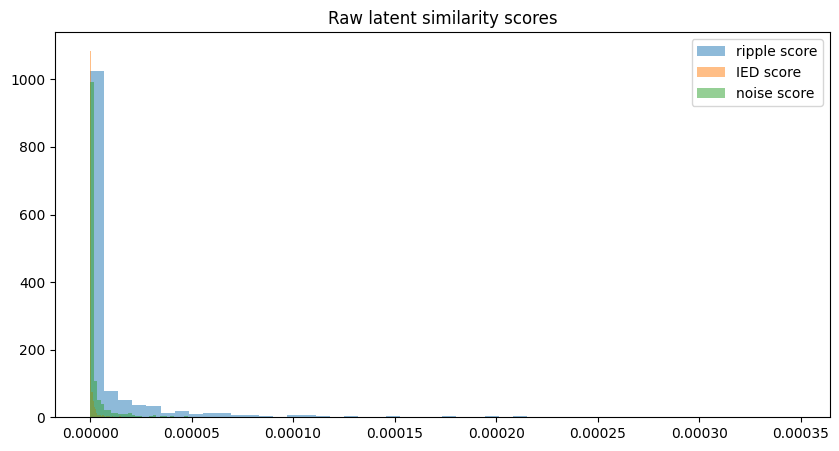

In [120]:
plt.figure(figsize=(10,5))

plt.hist(ripple_scores, bins=50, alpha=0.5, label="ripple score")
plt.hist(ied_scores, bins=50, alpha=0.5, label="IED score")
plt.hist(noise_scores, bins=50, alpha=0.5, label="noise score")

plt.legend()
plt.title("Raw latent similarity scores")
plt.show()

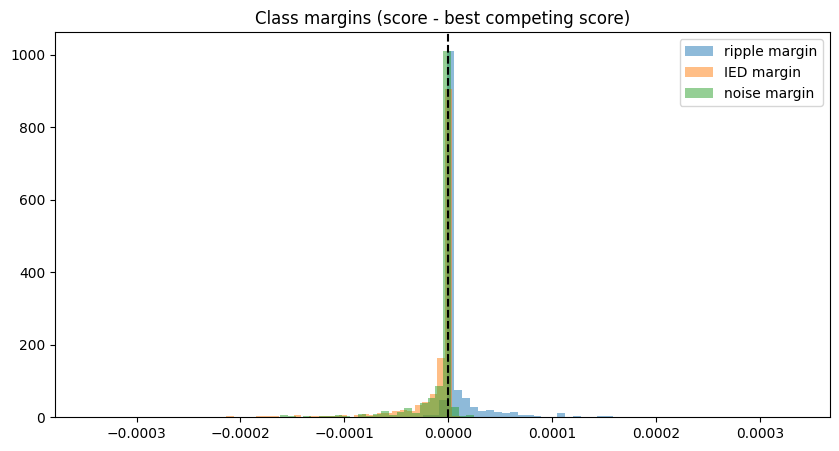

In [121]:
plt.figure(figsize=(10,5))

plt.hist(ripple_margin, bins=50, alpha=0.5, label="ripple margin")
plt.hist(ied_margin, bins=50, alpha=0.5, label="IED margin")
plt.hist(noise_margin, bins=50, alpha=0.5, label="noise margin")

plt.axvline(0, color="black", linestyle="--")

plt.legend()
plt.title("Class margins (score - best competing score)")
plt.show()

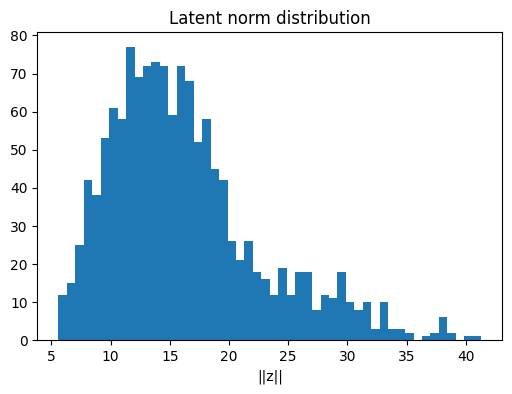

In [122]:
plt.figure(figsize=(6,4))
plt.hist(latent_norms, bins=50)
plt.title("Latent norm distribution")
plt.xlabel("||z||")
plt.show()

In [98]:
def get_latents(model, samples, device="cuda"):
    model.eval()

    latents = []
    labels = []
    subjects = []

    with torch.no_grad():
        for s in samples:
            x = torch.tensor(s["wave"], dtype=torch.float32).unsqueeze(0).to(device)

            z = model.encoder(x).squeeze(0).cpu().numpy()

            latents.append(z)
            labels.append(s["label"])
            subjects.append(s["animal_id"])

    return np.array(latents), np.array(labels), np.array(subjects)

def compute_prototypes(Z, y):
    prototypes = {}

    for c in [0, 1, 2]:
        prototypes[c] = Z[y == c].mean(axis=0)

    return prototypes

def classify_by_prototype(Z, prototypes):
    preds = []

    for z in Z:
        dists = {c: np.linalg.norm(z - prototypes[c]) for c in prototypes}
        pred = min(dists, key=dists.get)
        preds.append(pred)

    return np.array(preds)

def plot_latent(Z, y):
    from sklearn.decomposition import PCA

    Z2 = PCA(n_components=2).fit_transform(Z)

    plt.figure(figsize=(6,6))

    for c in [0, 1, 2]:
        idx = (y == c)
        plt.scatter(Z2[idx,0], Z2[idx,1], label=c, alpha=0.5)

    plt.legend()
    plt.title("Latent space separation")
    plt.show()

In [99]:
Z, y, s = get_latents(ripple_ae, val_samples)

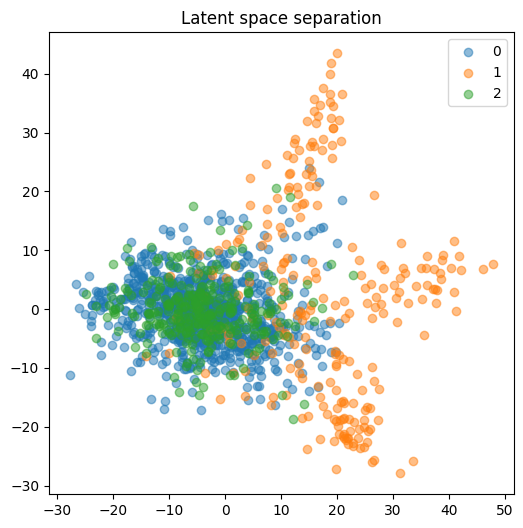

In [100]:
plot_latent(Z, y)

In [101]:
Z, y, s = get_latents(ied_ae, val_samples)

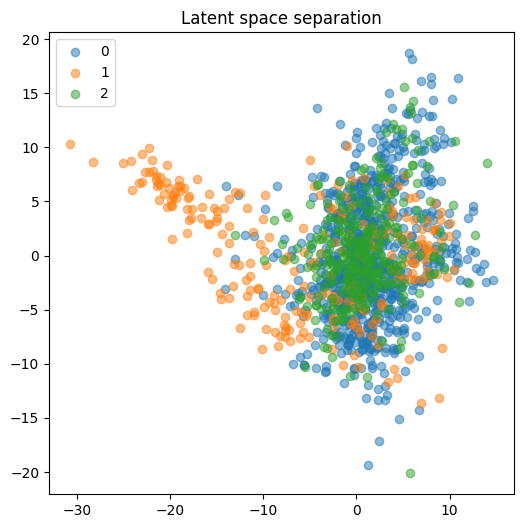

In [102]:
plot_latent(Z, y)

In [92]:
def plot_reconstructions_subset(model, samples, n_per_class=5, device="cuda", seed=0):
    random.seed(seed)

    model.eval()

    # group by label
    grouped = {0: [], 1: [], 2: []}

    for s in samples:
        grouped[s["label"]].append(s)

    def plot_group(group, title):
        # sample subset safely
        group = random.sample(group, min(n_per_class, len(group)))

        plt.figure(figsize=(12, 2.5 * len(group)))

        for i, s in enumerate(group):
            x = torch.tensor(s["wave"], dtype=torch.float32).unsqueeze(0).to(device)



            with torch.no_grad():
                x_hat = model(x)

            x = x.squeeze().cpu().numpy()
            x_hat = x_hat.squeeze().cpu().numpy()

            plt.subplot(len(group), 1, i + 1)
            plt.plot(x.T, label="orig", alpha=0.7, c='blue')
            plt.plot(x_hat.T, label="recon", alpha=0.7, c='red')

            err = ((x - x_hat) ** 2).mean().item()
            plt.title(f"{title} | subj={s['animal_id']} | err={err:.3f}")

            #plt.title(f"{title} | subj={s['animal_id']}")
            plt.legend(loc="upper right")

        plt.tight_layout()
        plt.show()

    for label in [0, 1, 2]:
        if len(grouped[label]) > 0:
            plot_group(grouped[label], label)

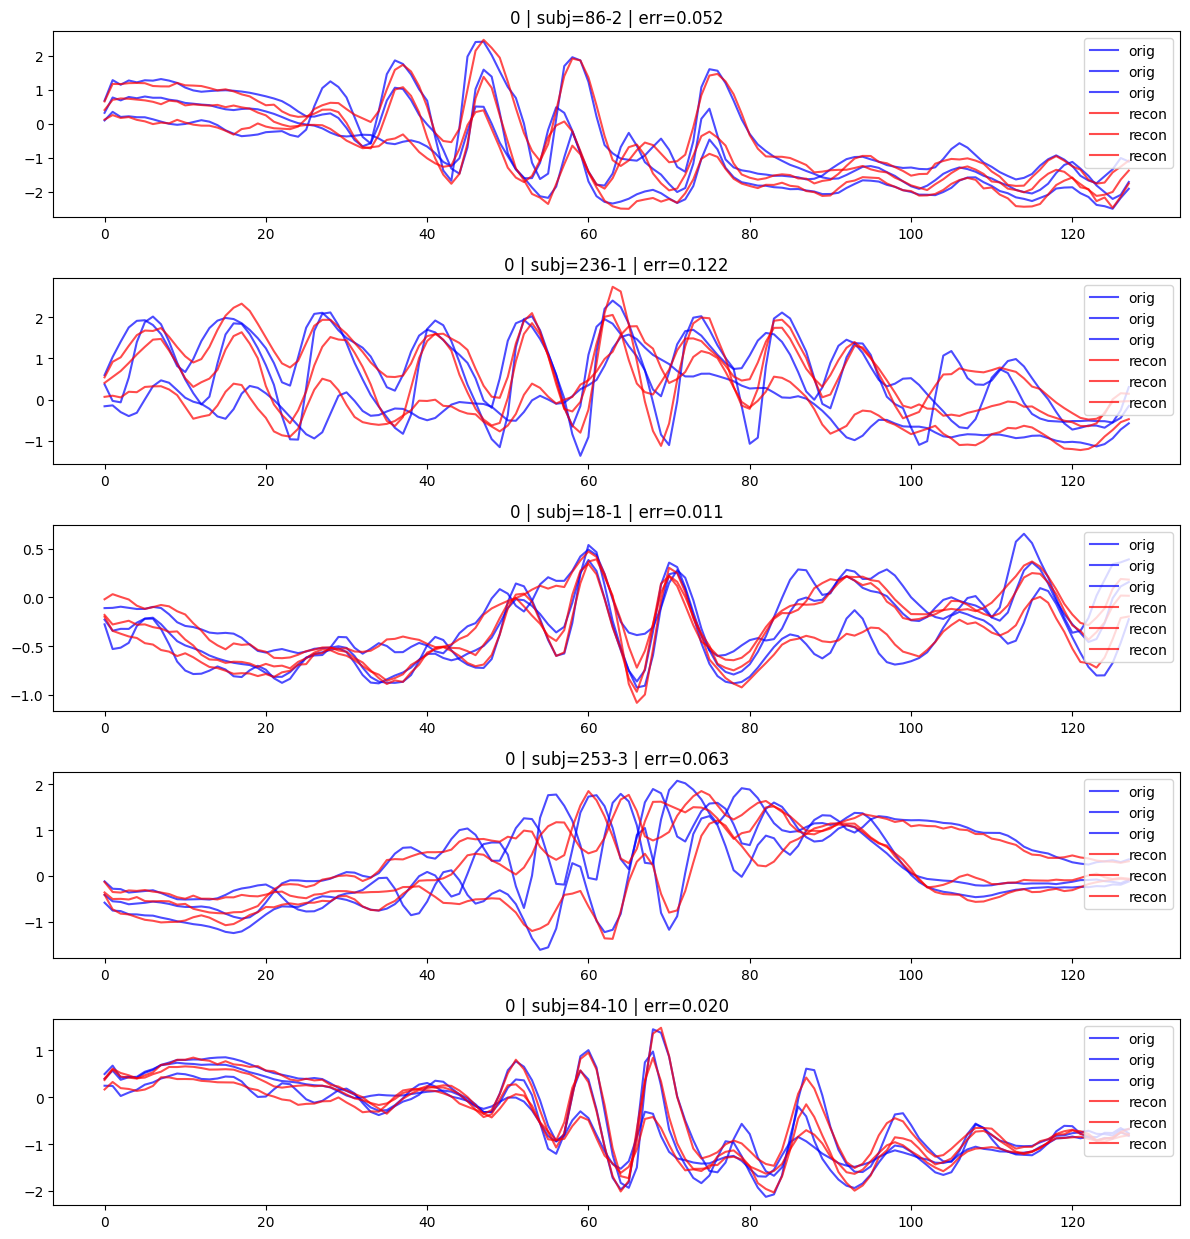

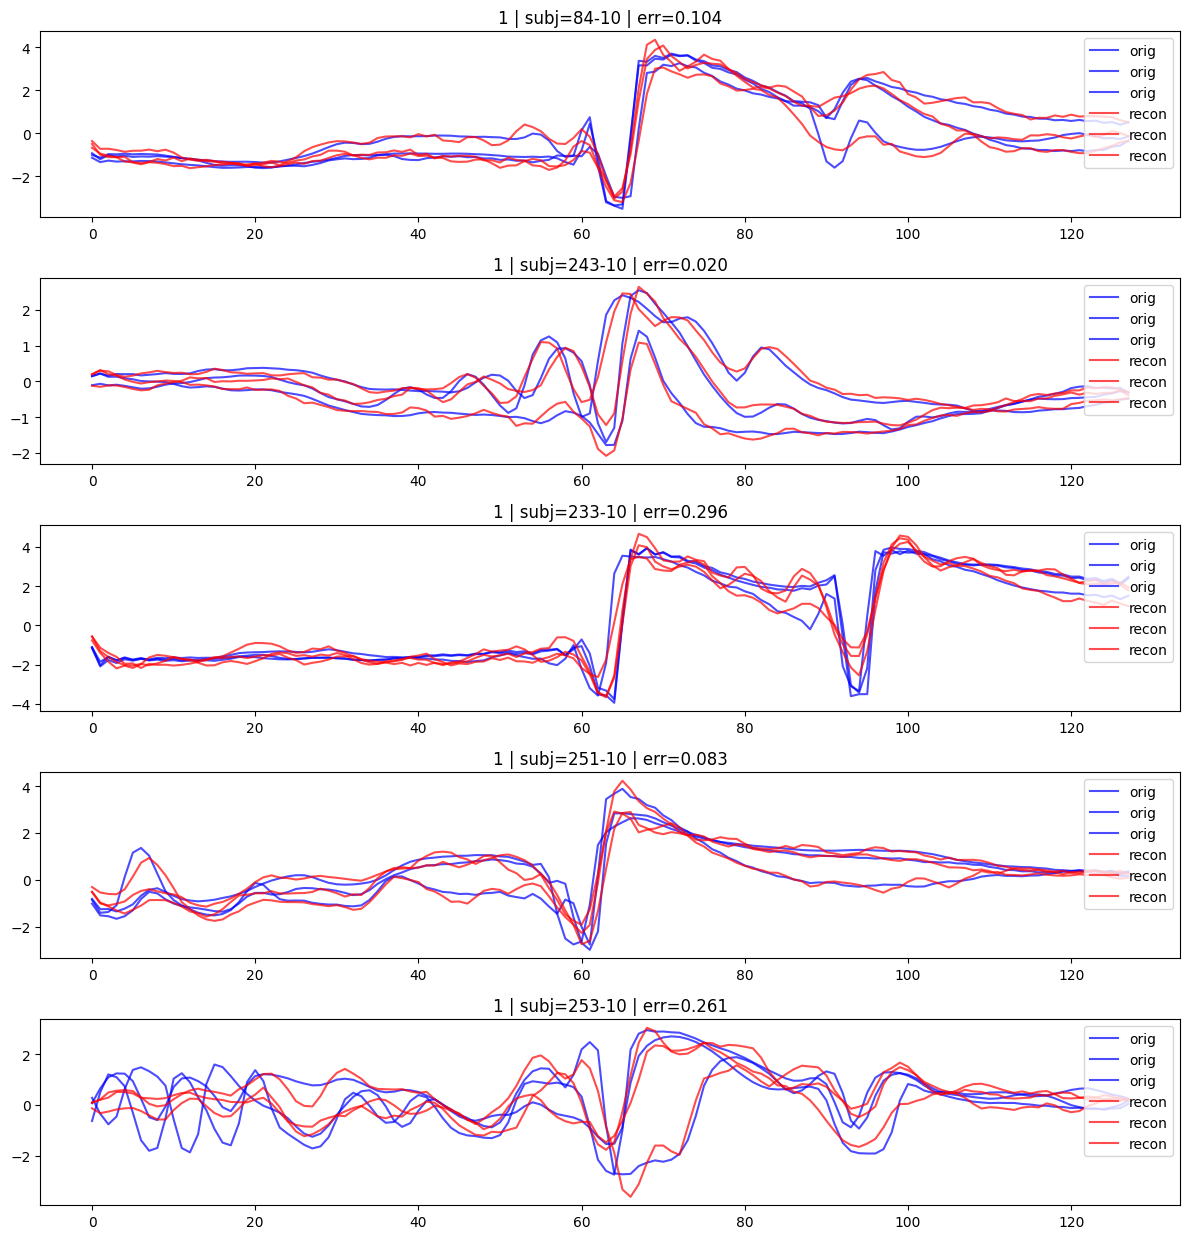

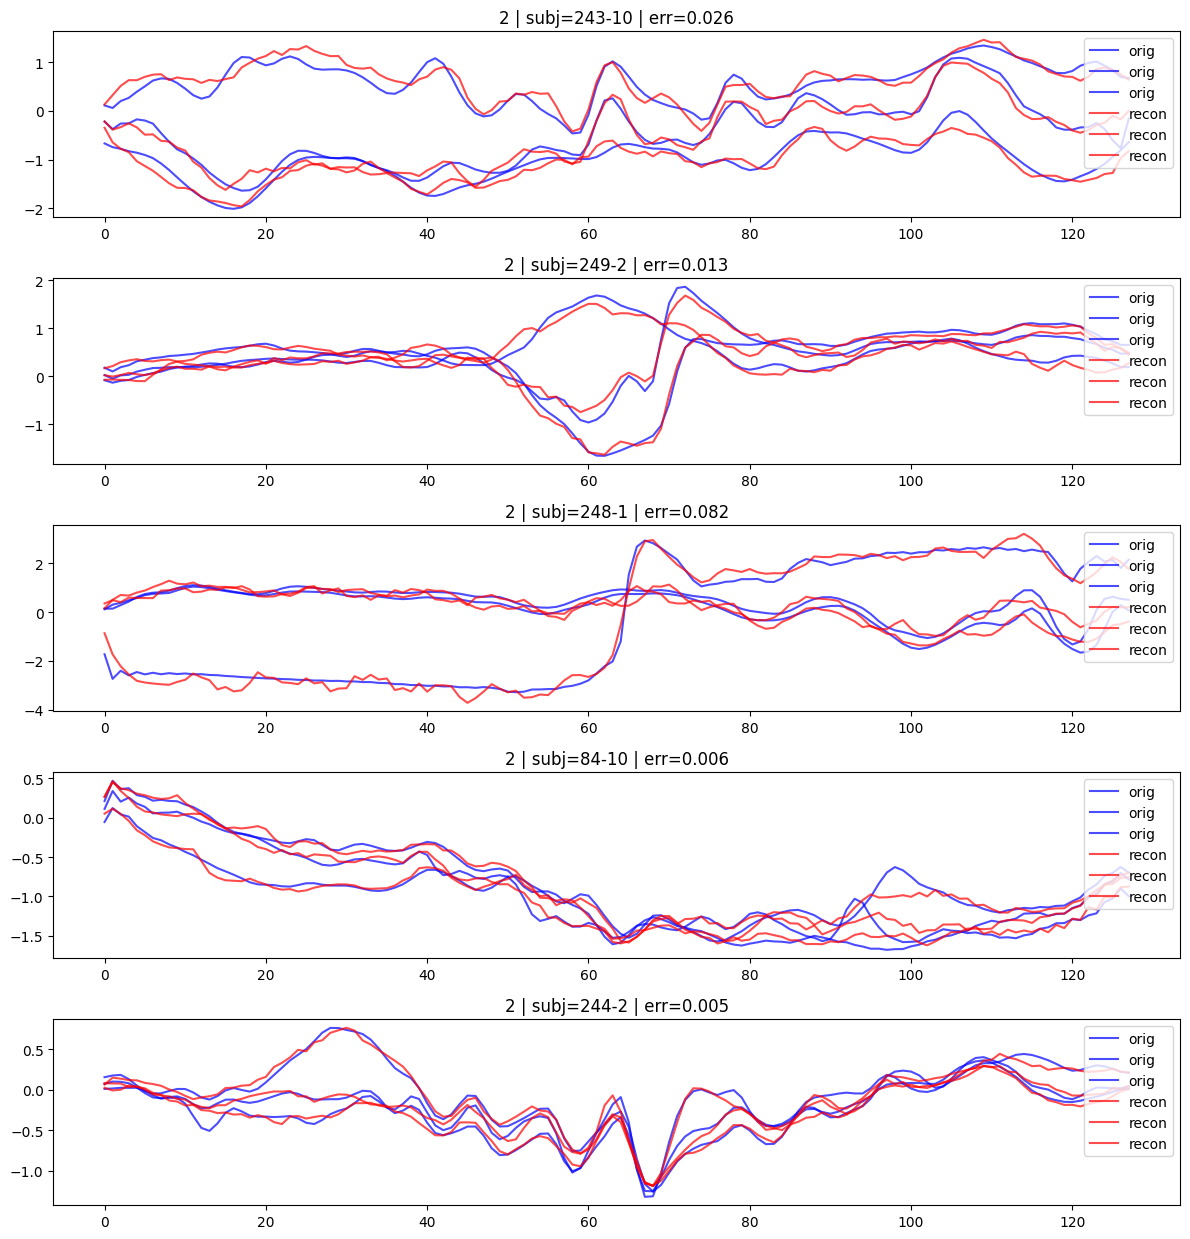

In [93]:
plot_reconstructions_subset(ripple_ae, samples, seed=5)

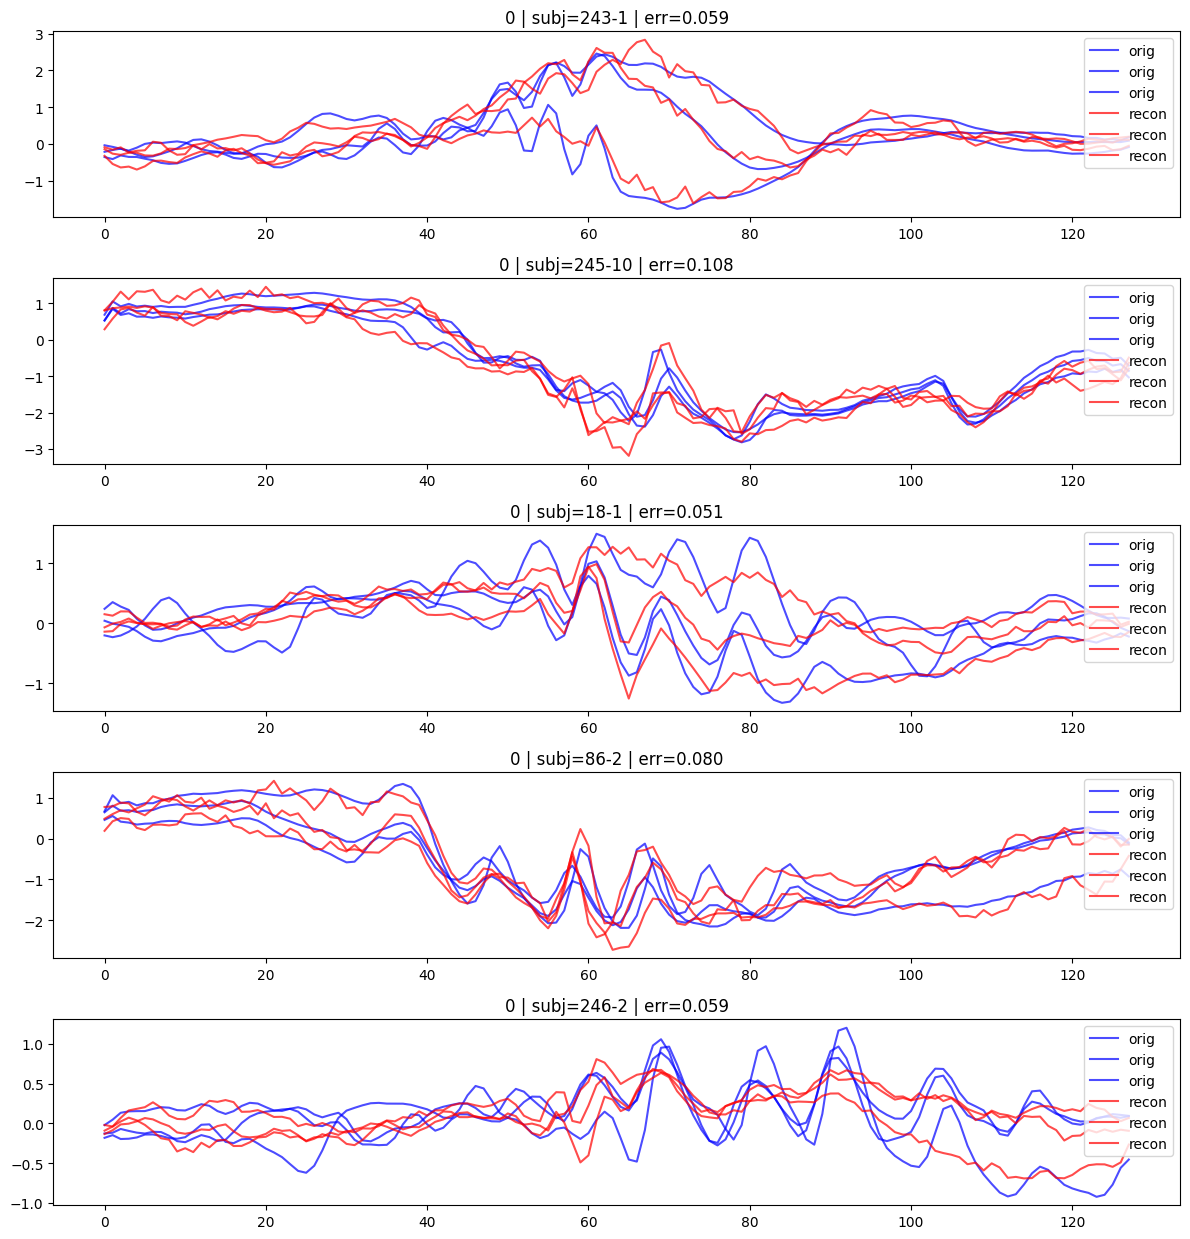

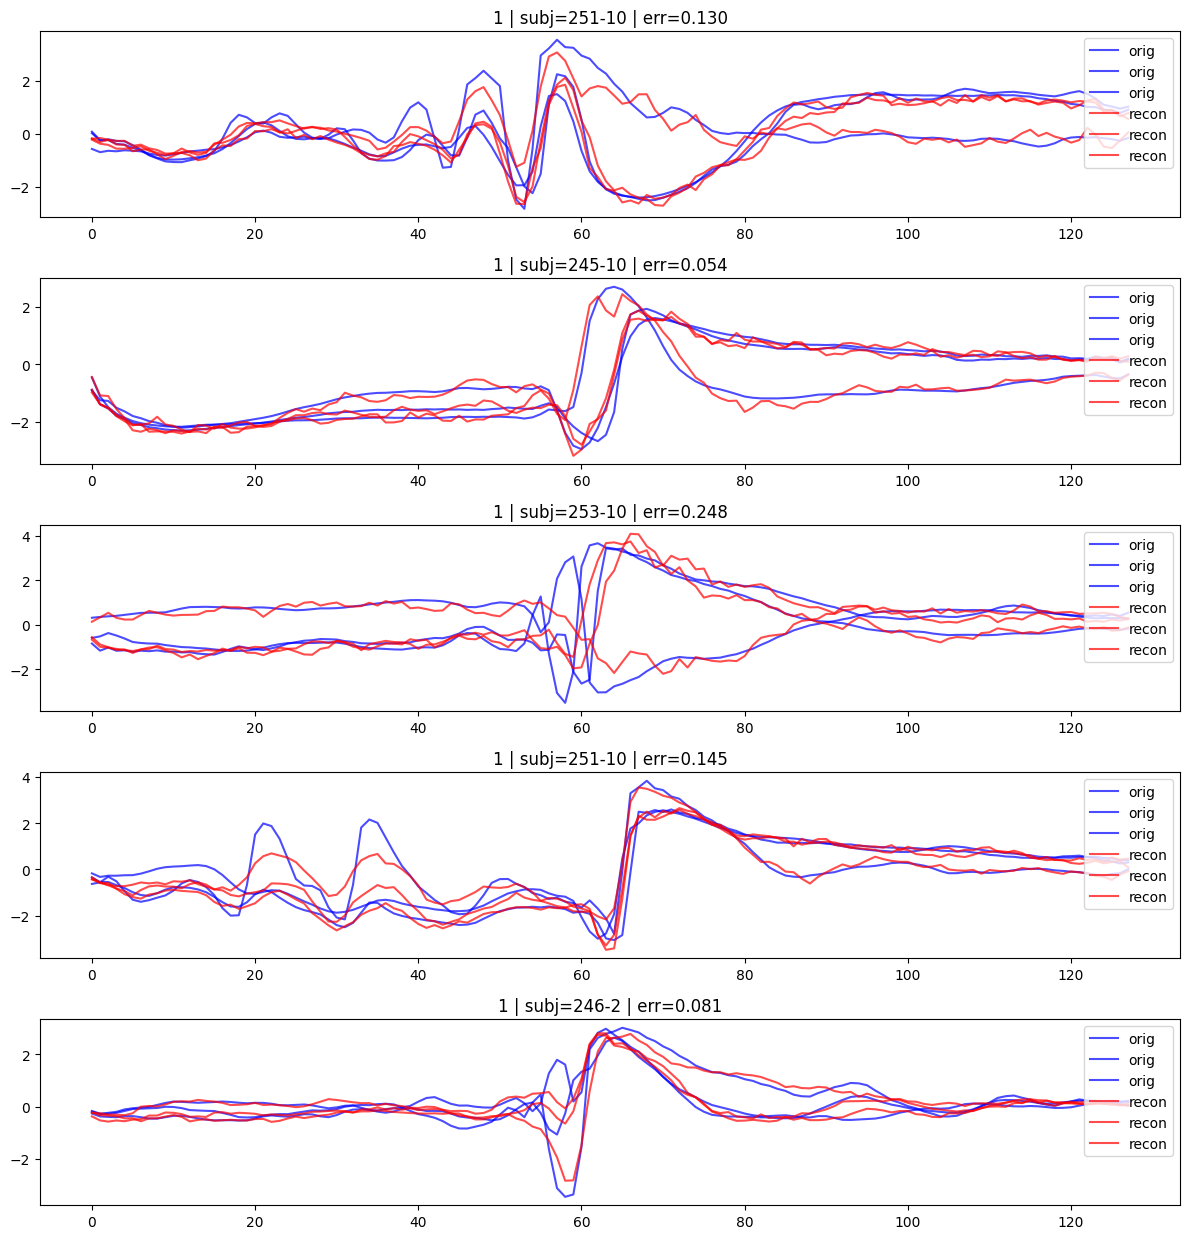

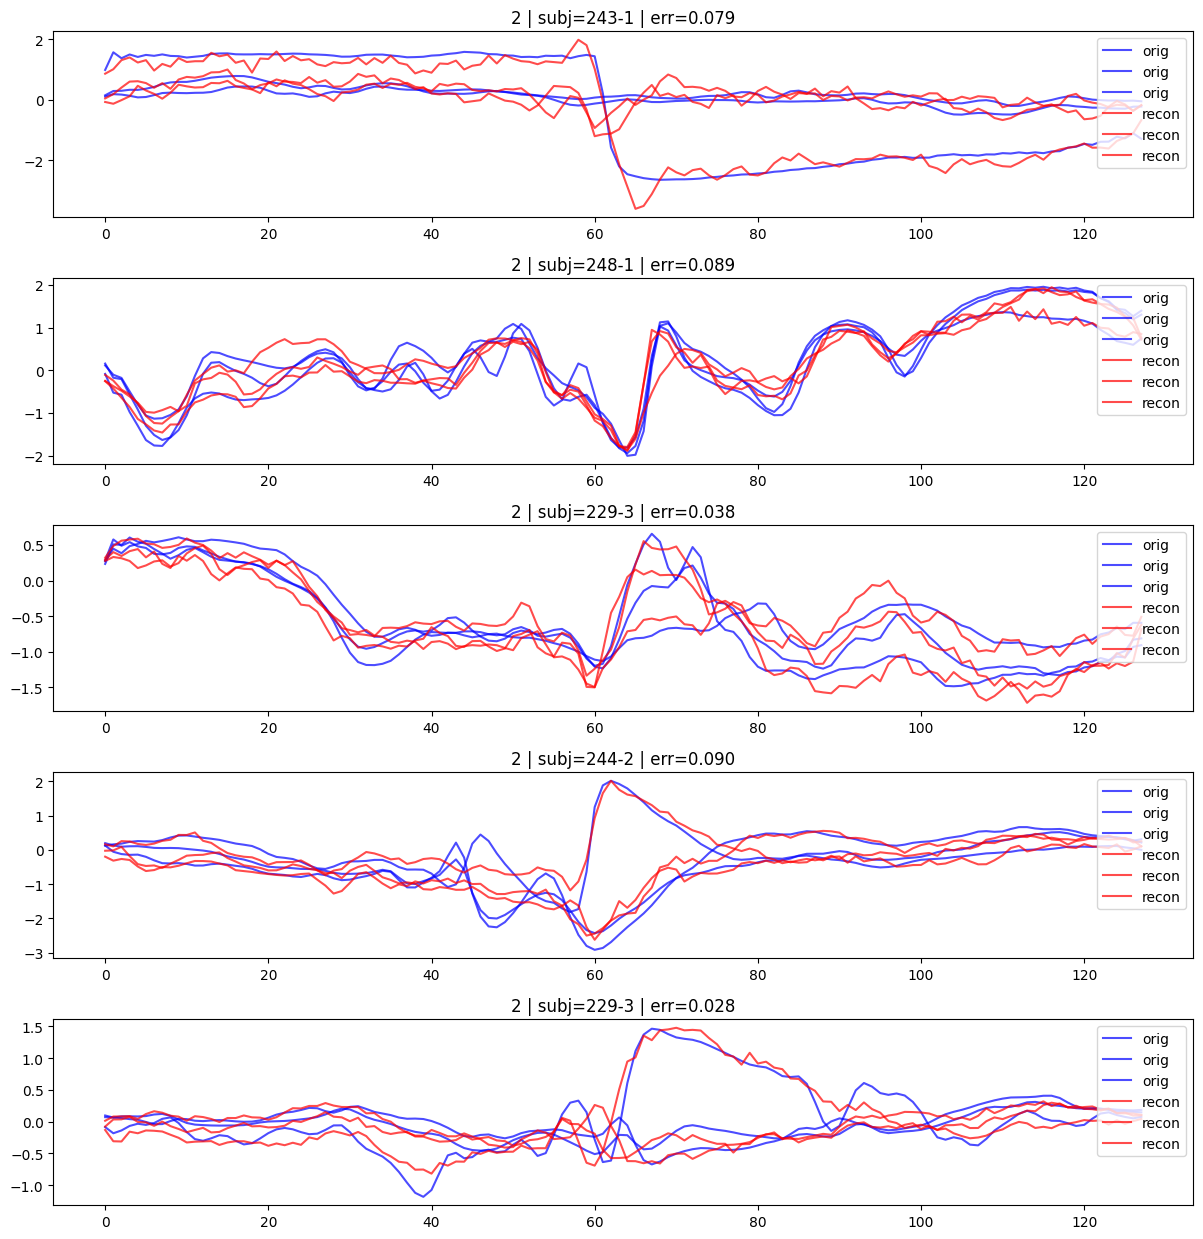

In [94]:
plot_reconstructions_subset(ied_ae, samples)